# Run PyBasin directly, without a subprocess

`notebooks/run_example_and_visualize.ipynb` runs PyBasin by calling `python pybasin.py example_dataset_1` as a subprocess, then reloads the saved `.pck` output file to visualize it. This notebook instead imports `pybasin.py` and the `lib` modules directly and calls the same functions `pybasin.py`'s own command line entry point (`main()`) calls, for a single well and a single (base case) model scenario, so the model result is a set of ordinary Python objects sitting in memory, not a subprocess return code and a file on disk.

This uses `example_dataset_1` (borehole NDW-01, Roer Valley Graben, southern Netherlands), the same dataset as the subprocess-based notebook, so the two can be compared directly.

This calls the exact function `pybasin.py`'s own command line entry point uses for a single model scenario, `update_model_params_and_run_model_new`, so the in-memory result computed here is the same as a subprocess run would produce; only the file and log output are skipped (`save_burial_csv_files=False`, `log_screen_output=False`). This code path is also exercised directly by `tests/test_example_datasets.py::test_example_dataset_1`.

## Setup

Add the project root to the Python path so `pybasin`, `lib.model_input_io`, `lib.pybasin_io` and `lib.pybasin_figures` can be imported as modules.

In [1]:
import os
import sys

import pandas as pd

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pybasin
import lib.model_input_io as model_input_io
import lib.pybasin_io as pybasin_io
import lib.pybasin_figures as pybasin_figures

dataset_name = 'example_dataset_1'
input_dir = os.path.join(PROJECT_ROOT, 'input_data', dataset_name)

INFO: import fortran annealing module ok


## Load the model parameters for this dataset

Every PyBasin input directory has its own `pybasin_params.py` file, defining a `ModelParameters` class. `pybasin.py`'s command line entry point loads this file with `importlib`, so that datasets in different directories can all define a same-named `pybasin_params` module without clashing, and so that worker processes in a parallel run can re-import it by name. This notebook only runs one dataset at a time in a single process, so a plain import after adding the input directory to `sys.path` is enough.

`update_model_params_and_run_model_new` mutates the `Parameters` instance in place (eg. the exhumation timing arrays), so re-running this notebook against a different dataset in the same kernel session needs a fresh `ModelParameters()` instance, not a reused one.

In [2]:
if input_dir not in sys.path:
    sys.path.insert(0, input_dir)

import pybasin_params

Parameters = pybasin_params.ModelParameters()

print(f"wells in this dataset: {Parameters.wells}")
print(f"simulate_VR={Parameters.simulate_VR}, "
     f"simulate_AFT={Parameters.simulate_AFT}, "
     f"simulate_He={Parameters.simulate_He}, "
     f"simulate_salinity={Parameters.simulate_salinity}")

----------
Example PyBasin dataset from the Roer Valley Graben (Luijendijk et al. 2011)
----------
wells in this dataset: ['NDW-01']
simulate_VR=True, simulate_AFT=True, simulate_He=False, simulate_salinity=False


## Read the input data files

`check_input_data_files` checks that every `.csv` file `Parameters` asks for is actually present, and `read_model_input_data` reads them all into pandas DataFrames. This is the same input data `python pybasin.py example_dataset_1` reads before running any well.

In [3]:
model_input_io.check_input_data_files(input_dir, Parameters)

(well_strats, strat_info_mod, salinity_bnd_df,
 T_data_df, vr_data_df,
 aft_samples, aft_ages,
 he_samples, he_data,
 salinity_data, surface_temp, litho_props,
 pressure_data, porosity_data) = model_input_io.read_model_input_data(
    input_dir, Parameters)

INFO: checking for input files in /Users/elcopone/werk/published_code/pybasin_git/input_data/example_dataset_1


INFO: found all necessary input files in /Users/elcopone/werk/published_code/pybasin_git/input_data/example_dataset_1


INFO: reading input data


## Select the well to run

`example_dataset_1` only has one well, `NDW-01`. `select_well_strat` picks out that well's rows from the `well_stratigraphy.csv` table read above; `well_strat_orig` is kept unchanged so the model can be re-run more than once from the same starting point, matching how the main loop in `pybasin.py` reuses it across model scenarios.

In [4]:
well = Parameters.wells[0]
well_number = 0

well_strat, well_strat_orig = model_input_io.select_well_strat(
    well, well_strats)

if (Parameters.simulate_salinity is True
       and Parameters.well_specific_surface_salinity_bnd is True):
    surface_salinity_well = model_input_io.select_well_salinity_bnd(
        well, salinity_bnd_df)
else:
    surface_salinity_well = None

print(f"running well {well}, {len(well_strat)} stratigraphic units")

running well NDW-01, 41 stratigraphic units


## Run the burial and thermal history model

`update_model_params_and_run_model_new` is the function `pybasin.py`'s `main()` calls for a single, non-parallel model scenario; it applies any scenario parameter overrides (none here, since `example_dataset_1` defines a single base case, so `param_names` and `param_set` are both empty) and then calls `run_model_and_compare_to_data`, which in turn calls the actual burial and thermal history solver, `lib.pybasin_lib.run_burial_hist_model`. `model_results_series` is an empty `pandas.Series` that the function fills in with summary statistics as it goes; `save_burial_csv_files=False` keeps this run entirely in memory, without writing anything to `model_output/`.

In [5]:
model_results_series = pd.Series(dtype=object)

# update_model_params_and_run_model_new() returns a shorter tuple than
# run_model_and_compare_to_data() (its more detailed statistics, eg.
# vr_rmse, salinity_gof and pressure_rmse, are instead recorded onto
# model_results_series when record_data=True, its default)
(well_number_out, well_out, model_scenario_number_out,
 model_run_data,
 T_model_data, T_gof, T_r2,
 C_data,
 vr_gof, vr_r2, VR_model_data,
 aft_age_gof, aft_age_error, aft_age_r2, AFT_data,
 he_age_gof, he_age_error, he_age_r2,
 He_model_data,
 pressure_gof, pressure_r2, Pressure_model_data,
 model_results_series) = pybasin.update_model_params_and_run_model_new(
    model_scenario_number=0,
    pybasin_params=Parameters,
    param_names=[],
    param_set=[],
    well_number=well_number,
    well=well,
    model_results_series=model_results_series,
    well_strat=well_strat.copy(),
    well_strat_orig=well_strat_orig,
    strat_info_mod=strat_info_mod,
    surface_temp=surface_temp,
    surface_salinity_well=surface_salinity_well,
    litho_props=litho_props,
    T_data=T_data_df,
    vr_data_df=vr_data_df,
    aft_samples=aft_samples,
    aft_ages=aft_ages,
    he_samples=he_samples,
    he_data=he_data,
    salinity_data=salinity_data,
    csv_output_dir=Parameters.datafile_output_dir,
    output_dir=Parameters.output_dir,
    log_screen_output=False,
    pressure_data=pressure_data,
    save_burial_csv_files=False)

INFO: found unit with thickness < 5.0 m, adding 5.0 m


INFO: found unit with thickness < 5.0 m, adding 5.0 m


INFO: decompacting


INFO: final calculated porosity, mean=0.17, range=0.00-0.34


INFO: final thermal conductivity, mean=2.47, range=1.94-5.50


...

INFO: vitrinite reflectance GOF = 0.33, R2 = 0.91


INFO: AFT age GOF = 0.32, R2 = -5.00


INFO: AFT age error = 103.36


INFO: 


/Users/elcopone/werk/published_code/pybasin_git/lib/AFTlib.py:350: RuntimeWarning: divide by zero encountered in log
  gamma = np.log((np.exp(age*1.0e6/a)-1) / b)


## Assemble the model output into the same format the built-in figures expect

`build_model_run_data` packages the raw arrays and model-data comparison objects returned above into the same named dict / xarray format that `pybasin_io.load_model_run_data` returns after reading a saved `.pck` file, so `pybasin_figures.model_vs_data_figure` and the custom plots below work identically whether the model was just run in this notebook or reloaded from disk.

In [6]:
(time_array_bp, surface_temp_array, basal_hf_array,
 z_nodes, active_nodes, T_nodes, node_strat, node_age,
 porosity_nodes, rho_nodes, P_ex_nodes) = model_run_data

model_run_data_fig = pybasin_io.build_model_run_data(
    time_array_bp, surface_temp_array, basal_hf_array,
    z_nodes, active_nodes, T_nodes, node_strat, node_age,
    T_model_data, C_data, VR_model_data, AFT_data, He_model_data,
    porosity_nodes=porosity_nodes, rho_nodes=rho_nodes,
    P_ex_nodes=P_ex_nodes,
    pressure_data=Pressure_model_data, porosity_data=porosity_data)

grid = model_run_data_fig['grid']

## Goodness-of-fit summary

GOF = 1 means the model exactly reproduces the measured data, GOF = 0 means every modelled value falls outside the measured uncertainty range. These come directly from the return values above, without needing to read the `model_results_*.csv` file `pybasin.py` would otherwise write.

In [7]:
print(f"temperature: GOF={T_gof:.2f}, R2={T_r2:.2f}")
if Parameters.simulate_VR is True:
    print(f"vitrinite reflectance: GOF={vr_gof:.2f}, R2={vr_r2:.2f}")
if Parameters.simulate_AFT is True:
    print(f"AFT age: GOF={aft_age_gof:.2f}, R2={aft_age_r2:.2f}, "
         f"error={aft_age_error:.2f}")

temperature: GOF=1.00, R2=0.29
vitrinite reflectance: GOF=0.33, R2=0.91
AFT age: GOF=0.32, R2=-5.00, error=103.36


## Model-versus-data figure (built-in)

`pybasin_figures.model_vs_data_figure()` is the same function PyBasin calls automatically after a model run (when `make_model_data_fig = True` in `pybasin_params.py`) to generate the `model_data_fig_*.png` file. Calling it here uses the in-memory result directly, with no file written or read in between.

INFO: adding panel for VR data


INFO: adding panel for AFT data


INFO: gridding T or salinity data vs time


/Users/elcopone/opt/anaconda3/envs/py313/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


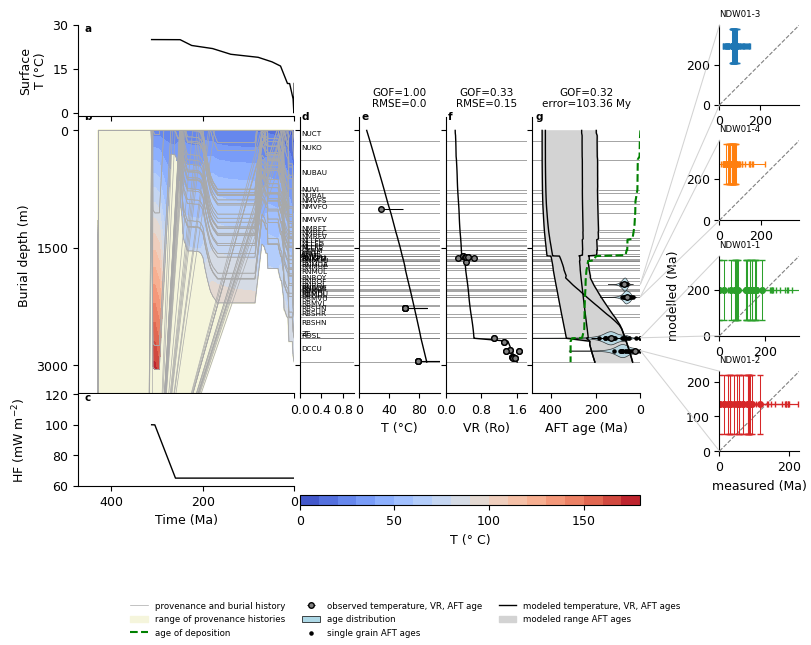

/Users/elcopone/opt/anaconda3/envs/py313/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)


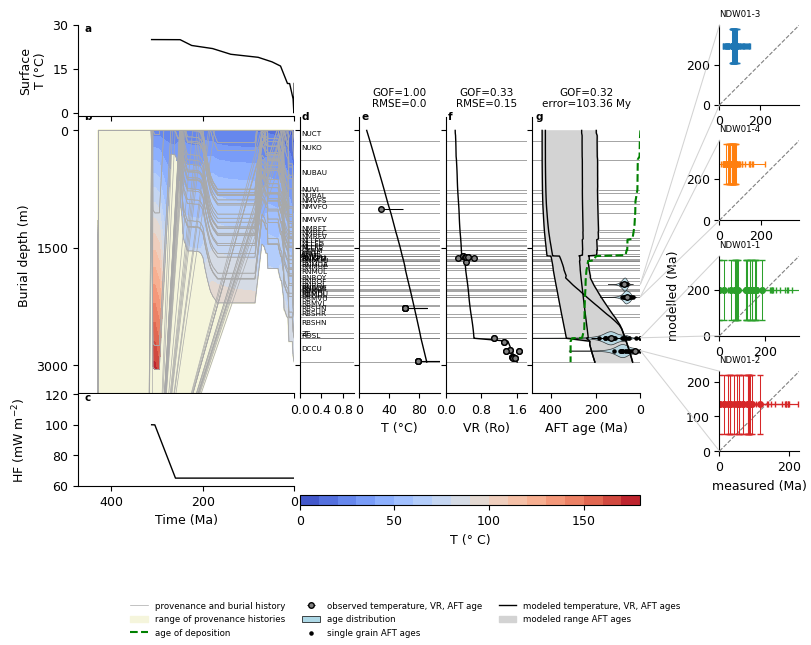

In [8]:
fig = pybasin_figures.model_vs_data_figure(
    model_run_data_fig, show_strat_column=True)
fig

## Custom plot: burial depth versus time

The panels above are generated by PyBasin's own plotting code. The cell below builds a simple additional plot directly from the raw model output, showing the modelled depth of every stratigraphic node over time. Each line is one node in the model; nodes that have not yet been deposited, or that have already been eroded, are not shown at that time (`grid['active']` marks which nodes exist at a given timestep).

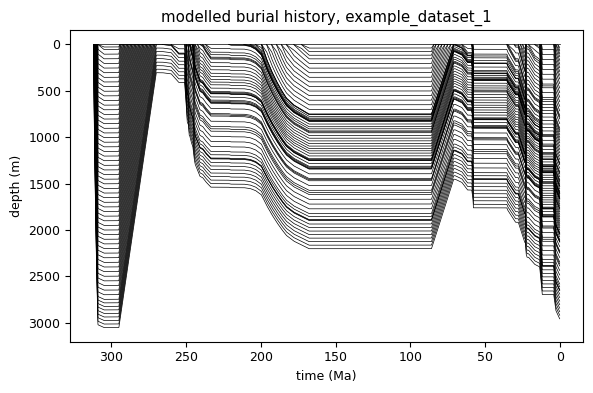

In [9]:
import matplotlib.pyplot as plt
import numpy as np

time_ma = grid['time'].values / 1e6
z_nodes_grid = grid['z'].values
active = grid['active'].values

fig2, ax = plt.subplots(figsize=(6, 4))
for node_i in range(z_nodes_grid.shape[1]):
    is_active = active[:, node_i]
    if is_active.any():
        ax.plot(time_ma[is_active], z_nodes_grid[is_active, node_i],
               color='black', lw=0.5)

ax.set_xlabel('time (Ma)')
ax.set_ylabel('depth (m)')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_title(f'modelled burial history, {dataset_name}')
fig2.tight_layout()

## Custom plot: modelled versus measured apatite fission track ages

`AFT_data` (present only if `simulate_AFT = True` for this dataset) holds the measured AFT age and its uncertainty for each sample, together with the modelled minimum and maximum age (the range spans the different provenance end-member histories used for that sample, see the manuscript section on provenance thermal histories). This plot compares them directly.

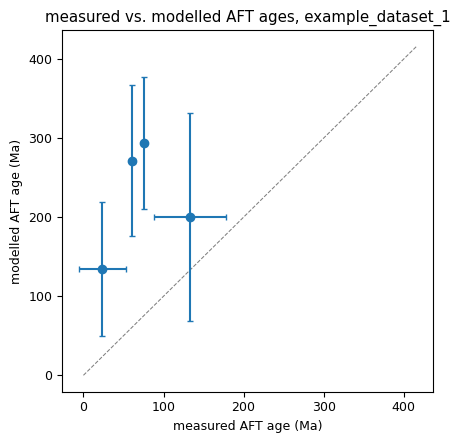

In [10]:
AFT_data_fig = model_run_data_fig.get('AFT_data')

if AFT_data_fig is None:
    print(f"{dataset_name} does not simulate AFT ages, nothing to "
         "plot here")
else:
    # AFT_data_fig['data'] is the per-sample dataframe used internally
    # for the goodness-of-fit calculation, with the measured age and
    # the modelled minimum and maximum age (spanning the different
    # provenance end-member histories) already matched up per sample
    aft_samples_df = AFT_data_fig['data']
    obs_age = aft_samples_df['aft_age'].values
    obs_err = aft_samples_df['aft_age_stderr_plus'].values
    sim_min = aft_samples_df['simulated_AFT_min'].values
    sim_max = aft_samples_df['simulated_AFT_max'].values

    fig3, ax3 = plt.subplots(figsize=(4.5, 4.5))
    max_age = max(obs_age.max(), sim_max.max()) * 1.1
    ax3.plot([0, max_age], [0, max_age], color='grey', ls='--', lw=0.75)
    ax3.errorbar(obs_age, (sim_min + sim_max) / 2.0, xerr=obs_err,
                yerr=(sim_max - sim_min) / 2.0, fmt='o', capsize=2)
    ax3.set_xlabel('measured AFT age (Ma)')
    ax3.set_ylabel('modelled AFT age (Ma)')
    ax3.set_title(f'measured vs. modelled AFT ages, {dataset_name}')
    fig3.tight_layout()